In [4]:
%matplotlib widget

In [5]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

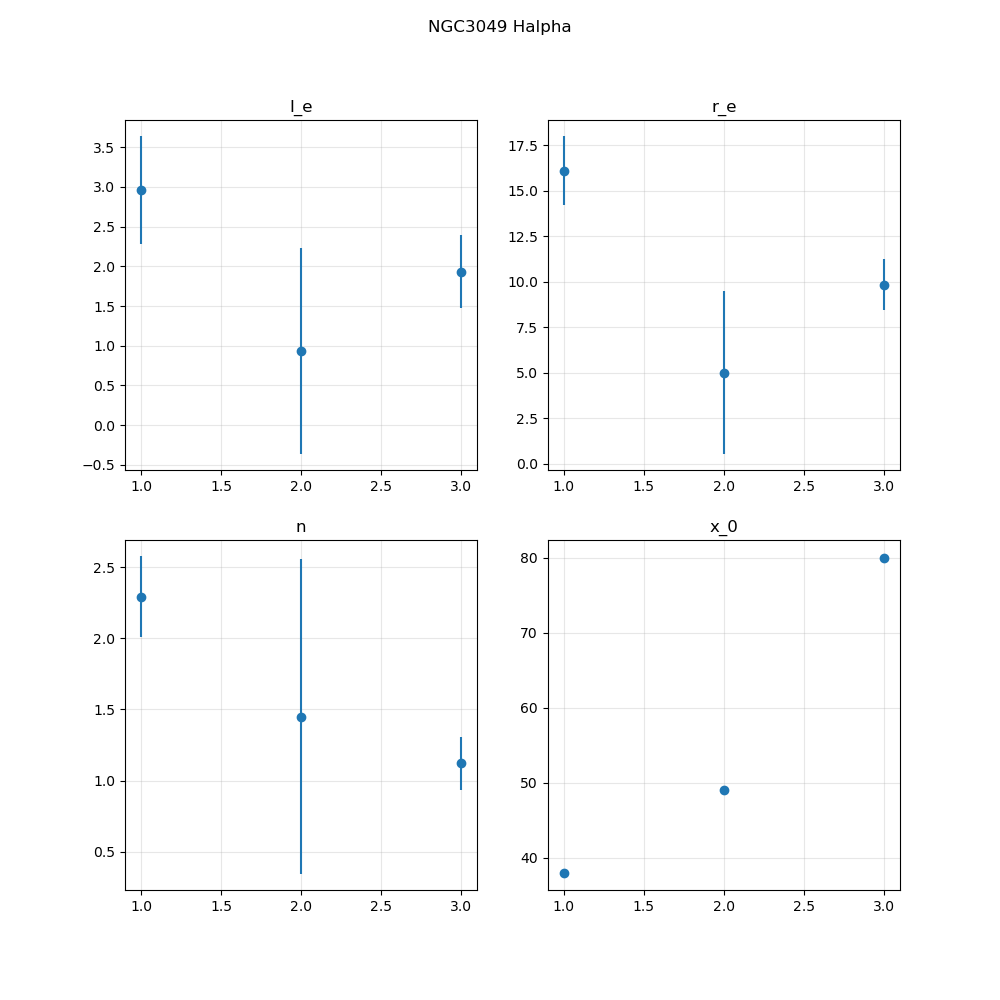

In [6]:
params = pd.read_csv("Halpha_fit.csv", index_col=0)
#I = df.iloc[0].to_numpy()
errors = pd.read_csv("Halpha_fit_errors.csv", index_col=0)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
peaks = [1, 2, 3]
plt.suptitle('NGC3049 Halpha')
ax[0][0].grid(alpha=0.3)
ax[0][0].errorbar(peaks, params.iloc[0].to_numpy(), errors.iloc[0].to_numpy(), marker='o', ls='none')
ax[0][0].set_title('I_e')
ax[0][1].grid(alpha=0.3)
ax[0][1].errorbar(peaks, params.iloc[1].to_numpy(), errors.iloc[1].to_numpy(), marker='o', ls='none')
ax[0][1].set_title('r_e')
ax[1][0].grid(alpha=0.3)
ax[1][0].errorbar(peaks, params.iloc[2].to_numpy(), errors.iloc[2].to_numpy(), marker='o', ls='none')
ax[1][0].set_title('n')
ax[1][1].grid(alpha=0.3)
ax[1][1].errorbar(peaks, params.iloc[3].to_numpy(), errors.iloc[3].to_numpy(), marker='o', ls='none')
ax[1][1].set_title('x_0')
plt.savefig('NGC3049_Halpha_params')

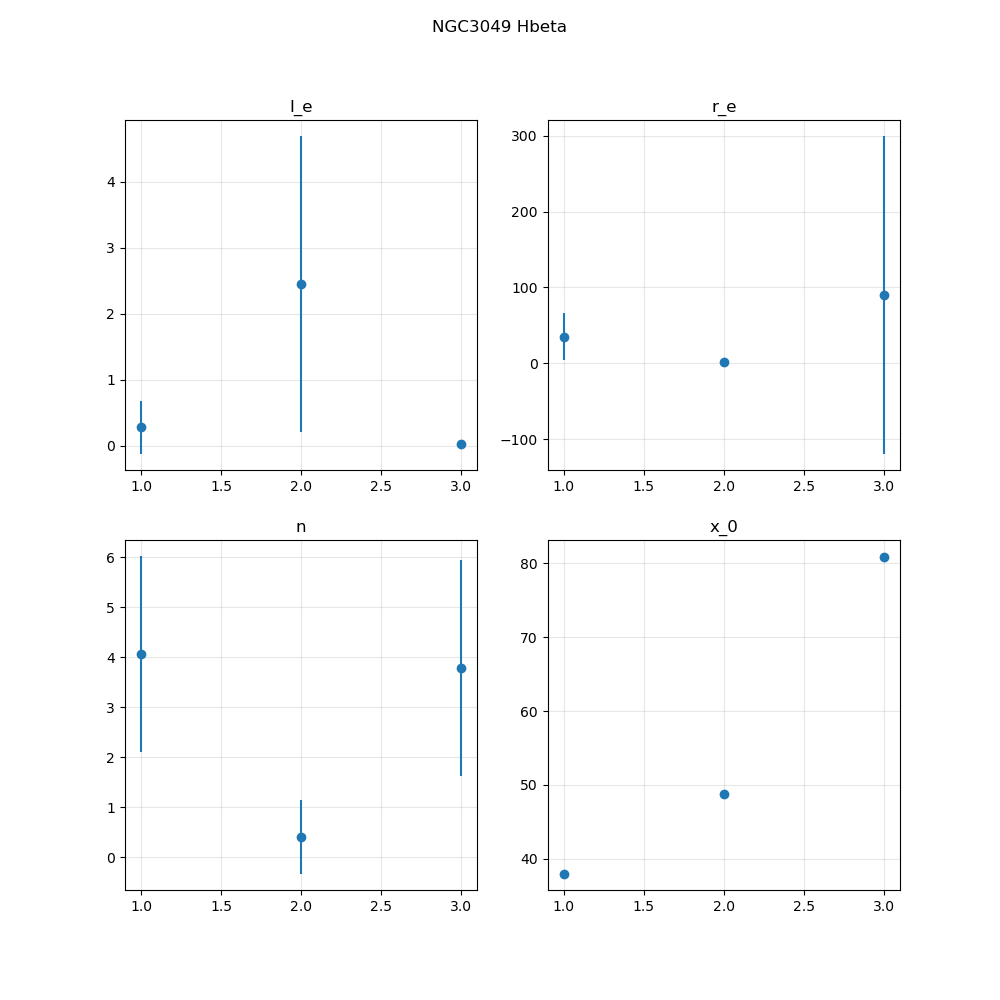

In [7]:
params = pd.read_csv("Hbeta_fit.csv", index_col=0)
#I = df.iloc[0].to_numpy()
errors = pd.read_csv("Hbeta_fit_errors.csv", index_col=0)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle('NGC3049 Hbeta')
ax[0][0].grid(alpha=0.3)
ax[0][0].errorbar(peaks, params.iloc[0].to_numpy(), errors.iloc[0].to_numpy(), marker='o', ls='none')
ax[0][0].set_title('I_e')
ax[0][1].grid(alpha=0.3)
ax[0][1].errorbar(peaks, params.iloc[1].to_numpy(), errors.iloc[1].to_numpy(), marker='o', ls='none')
ax[0][1].set_title('r_e')
ax[1][0].grid(alpha=0.3)
ax[1][0].errorbar(peaks, params.iloc[2].to_numpy(), errors.iloc[2].to_numpy(), marker='o', ls='none')
ax[1][0].set_title('n')
ax[1][1].grid(alpha=0.3)
ax[1][1].errorbar(peaks, params.iloc[3].to_numpy(), errors.iloc[3].to_numpy(), marker='o', ls='none')
ax[1][1].set_title('x_0')
plt.savefig('NGC3049_Hbeta_params')

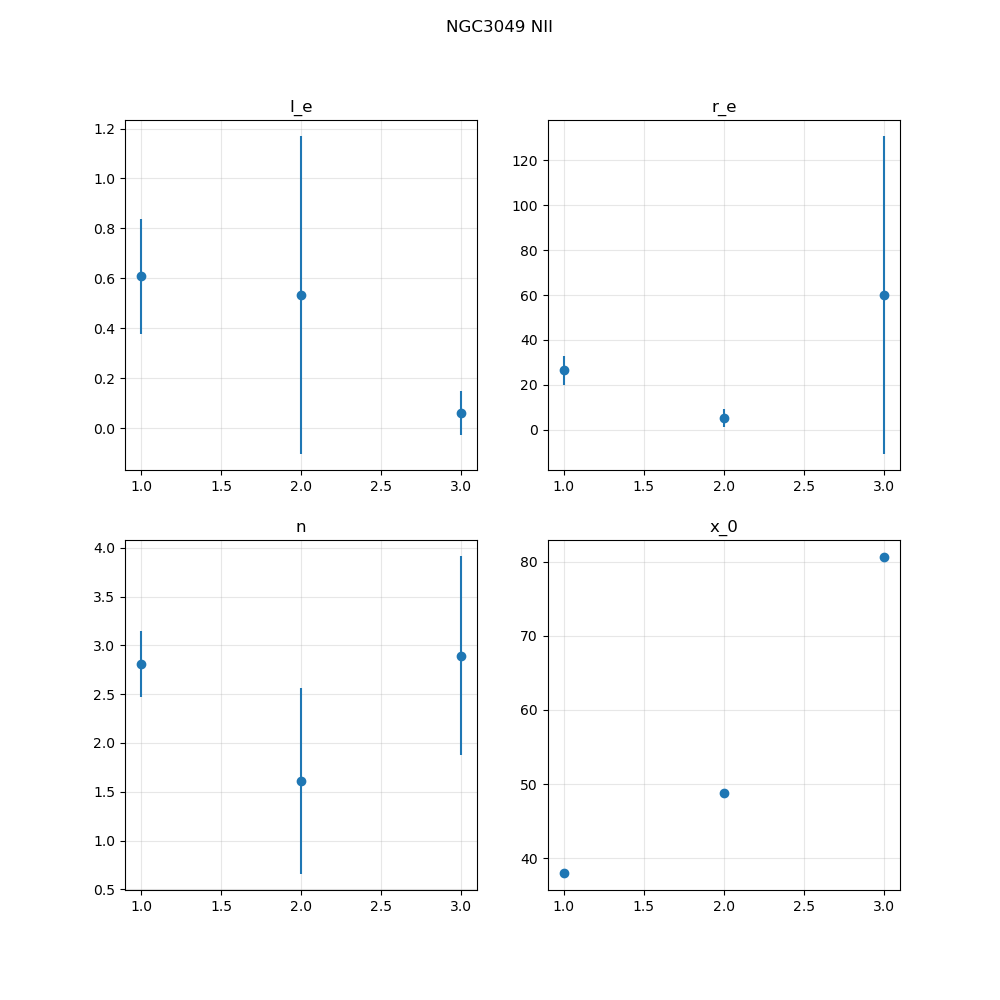

In [8]:
params = pd.read_csv("NII_fit.csv", index_col=0)
#I = df.iloc[0].to_numpy()
errors = pd.read_csv("NII_fit_errors.csv", index_col=0)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle('NGC3049 NII')
ax[0][0].grid(alpha=0.3)
ax[0][0].errorbar(peaks, params.iloc[0].to_numpy(), errors.iloc[0].to_numpy(), marker='o', ls='none')
ax[0][0].set_title('I_e')
ax[0][1].grid(alpha=0.3)
ax[0][1].errorbar(peaks, params.iloc[1].to_numpy(), errors.iloc[1].to_numpy(), marker='o', ls='none')
ax[0][1].set_title('r_e')
ax[1][0].grid(alpha=0.3)
ax[1][0].errorbar(peaks, params.iloc[2].to_numpy(), errors.iloc[2].to_numpy(), marker='o', ls='none')
ax[1][0].set_title('n')
ax[1][1].grid(alpha=0.3)
ax[1][1].errorbar(peaks, params.iloc[3].to_numpy(), errors.iloc[3].to_numpy(), marker='o', ls='none')
ax[1][1].set_title('x_0')
plt.savefig('NGC3049_NII_params')

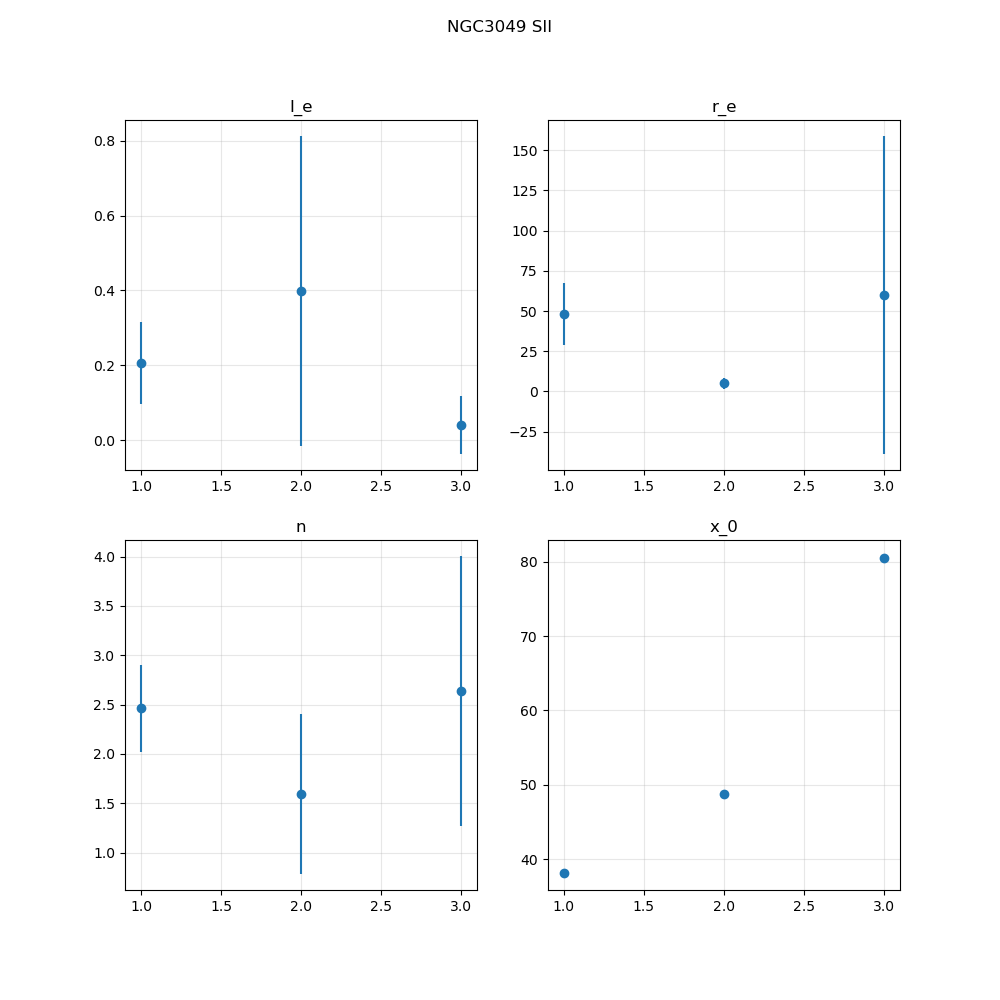

In [9]:
params = pd.read_csv("SII_fit.csv", index_col=0)
#I = df.iloc[0].to_numpy()
errors = pd.read_csv("SII_fit_errors.csv", index_col=0)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle('NGC3049 SII')
ax[0][0].grid(alpha=0.3)
ax[0][0].errorbar(peaks, params.iloc[0].to_numpy(), errors.iloc[0].to_numpy(), marker='o', ls='none')
ax[0][0].set_title('I_e')
ax[0][1].grid(alpha=0.3)
ax[0][1].errorbar(peaks, params.iloc[1].to_numpy(), errors.iloc[1].to_numpy(), marker='o', ls='none')
ax[0][1].set_title('r_e')
ax[1][0].grid(alpha=0.3)
ax[1][0].errorbar(peaks, params.iloc[2].to_numpy(), errors.iloc[2].to_numpy(), marker='o', ls='none')
ax[1][0].set_title('n')
ax[1][1].grid(alpha=0.3)
ax[1][1].errorbar(peaks, params.iloc[3].to_numpy(), errors.iloc[3].to_numpy(), marker='o', ls='none')
ax[1][1].set_title('x_0')
plt.savefig('NGC3049_SII_params')

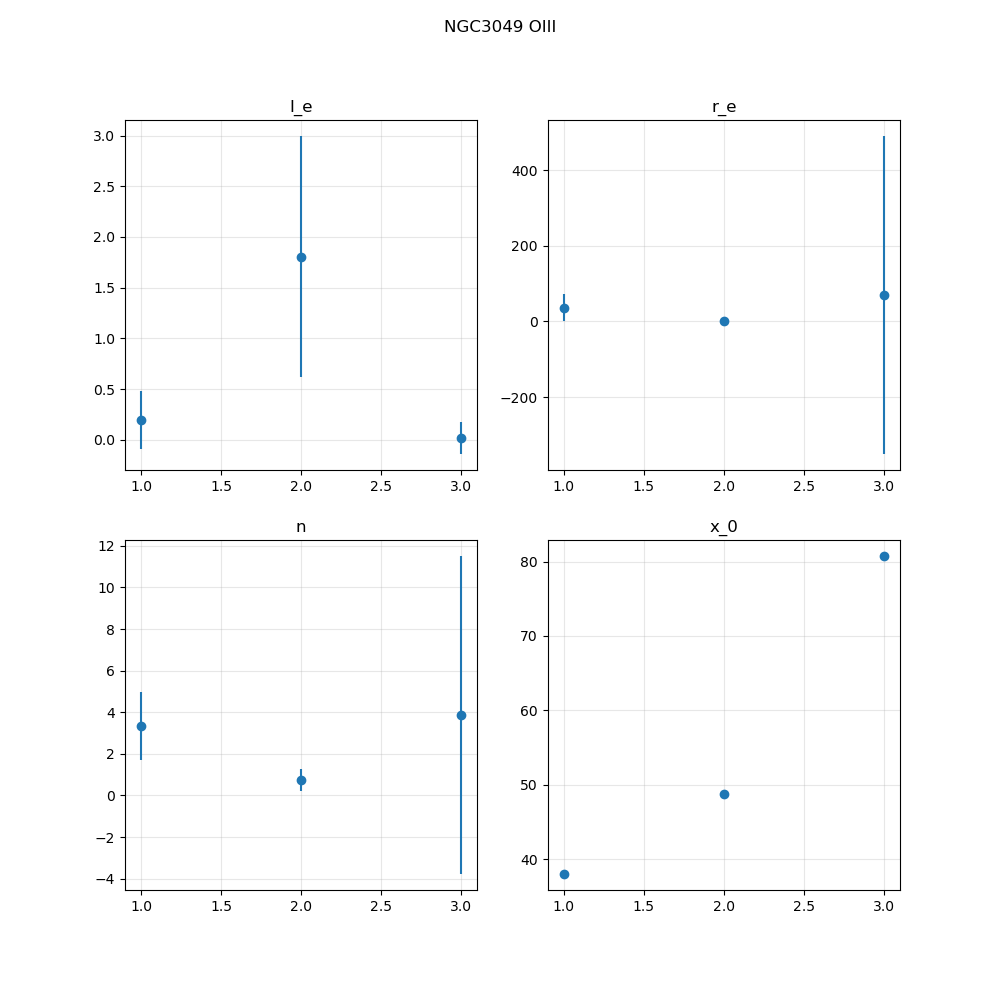

In [10]:
params = pd.read_csv("OIII_fit.csv", index_col=0)
#I = df.iloc[0].to_numpy()
errors = pd.read_csv("OIII_fit_errors.csv", index_col=0)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle('NGC3049 OIII')
ax[0][0].grid(alpha=0.3)
ax[0][0].errorbar(peaks, params.iloc[0].to_numpy(), errors.iloc[0].to_numpy(), marker='o', ls='none')
ax[0][0].set_title('I_e')
ax[0][1].grid(alpha=0.3)
ax[0][1].errorbar(peaks, params.iloc[1].to_numpy(), errors.iloc[1].to_numpy(), marker='o', ls='none')
ax[0][1].set_title('r_e')
ax[1][0].grid(alpha=0.3)
ax[1][0].errorbar(peaks, params.iloc[2].to_numpy(), errors.iloc[2].to_numpy(), marker='o', ls='none')
ax[1][0].set_title('n')
ax[1][1].grid(alpha=0.3)
ax[1][1].errorbar(peaks, params.iloc[3].to_numpy(), errors.iloc[3].to_numpy(), marker='o', ls='none')
ax[1][1].set_title('x_0')
plt.savefig('NGC3049_OIII_params')